In [1]:

import cv2
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
out_data = np.load("/home/jbauer/code/hp_mathematics/data/synthetic_blobs/training_results_0p5_0p5_0.01_gpu.npz")

In [3]:
out_data.files

['train_loss', 'train_acc', 'val_loss', 'val_acc', 'n_batches']

In [4]:
np.sqrt(len(out_data["n_batches"]))

np.float64(75.0)

In [16]:
out = out_data["val_acc"].reshape(75, 75)

In [17]:
sum(np.isnan(out_data["train_loss"]))/len(out_data["train_loss"])

np.float64(0.0)

In [18]:
out[np.isnan(out)] = 5

In [19]:
np.min(out)

np.float64(0.239375)

In [20]:
np.min(out_data["train_loss"])

np.float64(-0.00125)

In [21]:
lr_beta_vals = np.arange(0, 0.75, 0.01)

In [22]:
final_data = pd.pivot_table(pd.DataFrame(out), columns = lr_beta_vals, index = lr_beta_vals)

In [23]:
final_data

0                                                                ...  \
       0.00     0.01      0.02      0.03   0.04 0.05 0.06 0.07 0.08 0.09  ...   
0.00  0.255      NaN       NaN       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.01    NaN  0.33625       NaN       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.02    NaN      NaN  0.336875       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.03    NaN      NaN       NaN  0.326875    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.04    NaN      NaN       NaN       NaN  0.325  NaN  NaN  NaN  NaN  NaN  ...   
...     ...      ...       ...       ...    ...  ...  ...  ...  ...  ...  ...   
0.70    NaN      NaN       NaN       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.71    NaN      NaN       NaN       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.72    NaN      NaN       NaN       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.73    NaN      NaN       NaN       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   
0.74    NaN      NaN       NaN       NaN    NaN  NaN  NaN  NaN  NaN  NaN  ...   

       74                                                                     
     0.65 0.66 0.67 0.68 0.69      0.70      0.71     0.72    0.73      0.74  
0.00  NaN  NaN  NaN  NaN  NaN       NaN       NaN      NaN     NaN       NaN  
0.01  NaN  NaN  NaN  NaN  NaN       NaN       NaN      NaN     NaN       NaN  
0.02  NaN  NaN  NaN  NaN  NaN       NaN       NaN      NaN     NaN       NaN  
0.03  NaN  NaN  NaN  NaN  NaN       NaN       NaN      NaN     NaN       NaN  
0.04  NaN  NaN  NaN  NaN  NaN       NaN       NaN      NaN     NaN       NaN  
...   ...  ...  ...  ...  ...       ...       ...      ...     ...       ...  
0.70  NaN  NaN  NaN  NaN  NaN  0.319375       NaN      NaN     NaN       NaN  
0.71  NaN  NaN  NaN  NaN  NaN       NaN  0.343125      NaN     NaN       NaN  
0.72  NaN  NaN  NaN  NaN  NaN       NaN       NaN  0.31875     NaN       NaN  
0.73  NaN  NaN  NaN  NaN  NaN       NaN       NaN      NaN  0.3125       NaN  
0.74  NaN  NaN  NaN  NaN  NaN       NaN       NaN      NaN     NaN  0.343125  

[75 rows x 5625 columns]

In [24]:
out_loss = out_data["train_loss"].reshape(75, 75)
out_loss[out_loss < 0] = np.max(out_loss)

In [25]:
blurred_img = cv2.GaussianBlur(out, (3, 3), 2)

Text(0.5, 0, 'Momentum Value')

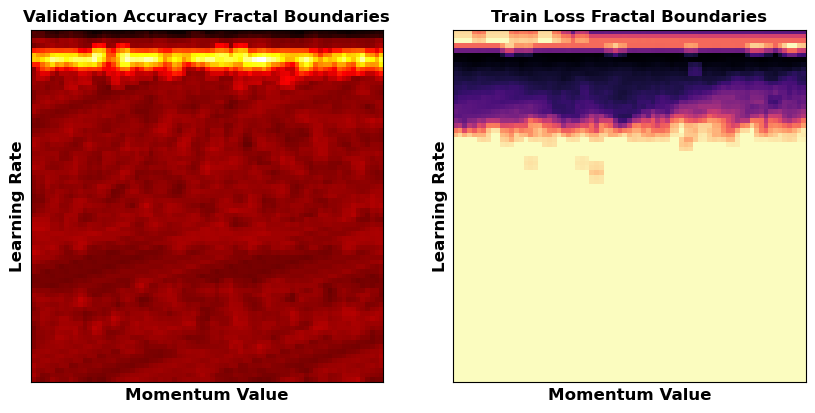

In [26]:

fig, ax = plt.subplots(1, 2,figsize = (10, 5))
ax[0].imshow(blurred_img, cmap = "hot")

# removes the grid labels
ax[0].set_xticks([])#list(range(blurred_img.shape[0])), lr_beta_vals)
ax[0].set_yticks([])#list(range(blurred_img.shape[1])), lr_beta_vals)

ax[0].set_title("Validation Accuracy Fractal Boundaries", weight = "bold", size = 12)
ax[0].set_ylabel("Learning Rate", weight = "bold", size = 12)
ax[0].set_xlabel("Momentum Value", weight = "bold", size = 12)

ax[1].imshow(cv2.GaussianBlur(out_loss, (3, 3), 2), cmap = "magma")

# removes the grid labels
ax[1].set_xticks([])#list(range(out_data[["n_batches"]].shape[0])), lr_beta_vals)
ax[1].set_yticks([])#list(range(out_data[["n_batches"]].shape[1])), lr_beta_vals)
ax[1].set_title("Train Loss Fractal Boundaries", weight = "bold", size = 12)
ax[1].set_ylabel("Learning Rate", weight = "bold", size = 12)
ax[1].set_xlabel("Momentum Value", weight = "bold", size = 12)

In [ ]:
np.max(out_data["val_acc"])

In [ ]:
np.max(out_data["train_acc"])